# Градиентрый спуск

## Основная часть

__Задача 1. (всего 5 баллов)__ Рассмотрим следуюущую задачу оптимизации:

\begin{equation}
\min_{x \in \mathbb{R}^d} \left[f(x) := \tfrac{1}{2} x^T A x - b^T x\right],
\end{equation}
где $A \in \mathbb{R}^{d \times d}$, такая, что $A + A^T$ - положительно определенная матрица, $b \in \mathbb{R}^d$.

__а). (0.5 балла)__ Докажите, что константа сильной выпуклости для этой задачи $\mu = \frac{1}{2} \lambda_{\min} \left(A + A^T\right)$, где $\lambda_{\min}(A)$ - минимальное собственное значение матрицы $A$.

__Ваше решение__
Рассмотрим функцию
\begin{equation}
f(x)=\frac{1}{2}x^T A x - b^T x
\end{equation}
Заметим, что для любого \begin{equation} x\in\mathbb{R}^d\end{equation}  верно равенство
\begin{equation}
x^T A x = x^T \frac{A + A^T}{2} x
\end{equation}
так как \begin{equation}x^T(A-A^T)x = 0\end{equation} (любая квадратичная форма, построенная с участием антисимметричной матрицы, равна нулю). Следовательно, функцию можно записать в виде
\begin{equation}f(x)=\frac{1}{4} x^T (A+A^T)x - b^T x. \end{equation}
Вычислим градиент:
\begin{equation}
\nabla f(x)=\frac{1}{2}(A+A^T)x - b
\end{equation}
а затем и гессиан:
\begin{equation}f(x)=\frac{1}{2}(A+A^T) \end{equation}
При условии, что \begin{equation} A+A^T \end{equation} положительно определён, минимальное собственное значение гессиана равно
\begin{equation}
\lambda_{\min}\left(\frac{1}{2}(A+A^T)\right)=\frac{1}{2}\lambda_{\min}(A+A^T). \end{equation}
По определению сильной выпуклости функция f является μ–сильновыпуклой, если \begin{equation} \nabla^2 f(x) \succeq \mu I\end{equation}  для всех xx. Отсюда получаем, что константа сильной выпуклости равна
\begin{equation}\mu=\frac{1}{2}\lambda_{\min}(A+A^T).\end{equation}


__б). (0.5 балла)__ Докажите, что константа Липшица для данной задачи $L = \frac{1}{2}\lambda_{\max}\left(A + A^T\right)$, где $\lambda_{max}(A)$ - максимально собственное значние матрицы $A$.

__Ваше решение__
Аналогично предыдущему пункту, имеем
\begin{equation} \nabla^2 f(x)=\frac{1}{2}(A+A^T). \end{equation}
Константа Липшица градиента L определяется как операторная норма (то есть максимальное собственное значение) гессиана:
\begin{equation} L=\lambda_{\max}\left(\frac{1}{2}(A+A^T)\right)=\frac{1}{2}\lambda_{\max}(A+A^T). \end{equation}
Таким образом, доказана формула для константы Липшица:
\begin{equation} L=\frac{1}{2}\lambda_{\max}(A+A^T). \end{equation}


__в). (1 балл)__ Предложите способ генерации матрицы $А$ так, чтобы $f$ была сильно выпуклой, а также можно было задавать и менять $d, \mu, L$. Докажите, что способ корректен.

_Hint:_ Диагональная матрица даст только 0.25 балла в данном пункте.

__Ваше решение__
Сгенерируйте ортогональную матрицу \begin{equation}Q \in \mathbb{R}^{d\times d}\end{equation}
Построем диагональную матрицу \begin{equation}D = \operatorname{diag}(d_1, d_2, \dots, d_d)\end{equation}, где d_i выбираются так, чтобы \begin{equation}\mu \leq d_i \leq L. \end{equation}
Определием \begin{equation}S = Q D Q^T\end{equation} Тогда собственные значения SS лежат в отрезке [μ,L]

Сгенерируйте случайную матрицу M и определите \begin{equation}N=\frac{M-M^T}{2}\end{equation}

Определием A = S + N.
Тогда
\begin{equation}A + A^T = (S+N) + (S+N)^T = 2S. \end{equation}
Это означает, что
\begin{equation}\lambda_{\min}(A+A^T)=2\lambda_{\min}(S) \quad \text{и} \quad \lambda_{\max}(A+A^T)=2\lambda_{\max}(S). \end{equation}
Таким образом, константы сильной выпуклости и Липшица для ff будут равны:
\begin{equation}\mu=\frac{1}{2}\cdot 2\lambda_{\min}(S)=\lambda_{\min}(S) \end{equation}
и
\begin{equation}
L=\frac{1}{2}\cdot 2\lambda_{\max}(S)=\lambda_{\max}(S)\end{equation}
Выбирая диагональные элементы D в интервале [μ,L], можно задать требуемые значения μ и L. Добавление не нулевой антисимметричной матрицы N обеспечивает, что матрица A не является просто диагональной или симметричной.


In [ ]:
#Ваше решение

__г). (0.5 балла)__  Реализуйте метод градиетного спуска:
\begin{equation}
x_{k+1} = x_k - \gamma_k \nabla f(x_k),
\end{equation}
для квадратичной функции с матрицей, которую сгенерировали выше, и произвольным ненулевым вектором $b$.

Используйте предложенную функцию для реализации алгоритма и допишите недостающие фрагменты. После чего для проверки загрузите функцию в [контест](https://contest.yandex.ru/contest/66540/enter/).

In [ ]:
from tqdm.autonotebook import tqdm
import numpy as np

def GradientDescent(grad, criterion, x_0, eps, max_iter, **params):

    '''
       grad(x) - функция, которая считает градиент целевой функции;
       criterion(x) - функция, которая считает критерий;
       x_0 - начальная точка;
       eps - точность сходимости (обычно 1e-8);
       max_iter - количество итераций;
       **params - содержит именнованные гиперпараметры метода:
           params['gamma'](k) - шаг, зависящий от номера итерации.
    '''

    errors = []

    x_k = np.copy(x_0)
    err_x_0 = criterion(x_k)
    errors.append(criterion(x_k) / err_x_0)
    for k in tqdm(range(max_iter)):
        gamma_k= params['gamma'](k)
        x_k= x_k - gamma_k * grad(x_k)
        # your code

        errors.append(criterion(x_k) / err_x_0)
        if errors[-1] < eps:
            break

    return x_k, errors

In [ ]:
#ваше решение

__д). (0.5 балла)__ Для задачи с $d = 50$, $\mu = 1$ и $L = 100$ найдите точное решение $x^*$ - выпишите формулу для решения в явном виде, а затем, реализуйте, например, с помощью пакетов линейной алгебры (есть встроенный в numpy).

__Ваше решение__

In [ ]:
#ваше решение
def generate_matrix_A(d, mu, L):
    Q, _= np.linalg.qr(np.random.randn(d, d))
    D= np.diag(np.random.uniform(mu, L, d))
    S= Q @ D @ Q.T
    M= np.random.randn(d, d)
    N= (M - M.T) / 2.0
    A= S + N
    return A

d= 50
mu= 1
L= 100
A= generate_matrix_A(d, mu, L)
b= np.random.randn(d)

A_sym= (A + A.T) / 2.0
x_star= np.linalg.solve(A_sym, b)

A_sym

array([[49.90247154,  0.38959266, -2.15630126, ...,  5.89100845,
         5.76704996,  5.48387359],
       [ 0.38959266, 59.61961522,  1.29275106, ..., -4.86132124,
        -3.56906884,  2.72522428],
       [-2.15630126,  1.29275106, 53.26435218, ..., 10.32794838,
        -1.78914779,  3.55854045],
       ...,
       [ 5.89100845, -4.86132124, 10.32794838, ..., 50.07416229,
        -4.44919841,  0.50215473],
       [ 5.76704996, -3.56906884, -1.78914779, ..., -4.44919841,
        58.32921407, -1.8262148 ],
       [ 5.48387359,  2.72522428,  3.55854045, ...,  0.50215473,
        -1.8262148 , 50.09536266]])

__е). (1.5 балл)__ Запустите градиентный спуск на $10^3$ итераций с шагом $\gamma_k = \tfrac{1}{L}$ и произвольной начальной точкой $x^0$ (если $b$ ненулевой, то можно взять нулевой $x^0$). Проверьте сходится ли он. В качестве критерия сходимости используйте $\| x_k - x^*\|^2_2$. Постройте график сходимости:
- по оси абцисс - номер итерации, по ординат - значения критерия на этой итерации.

Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д.. Графики должны быть удобны для чтения.

  0%|          | 0/1000 [00:00<?, ?it/s]

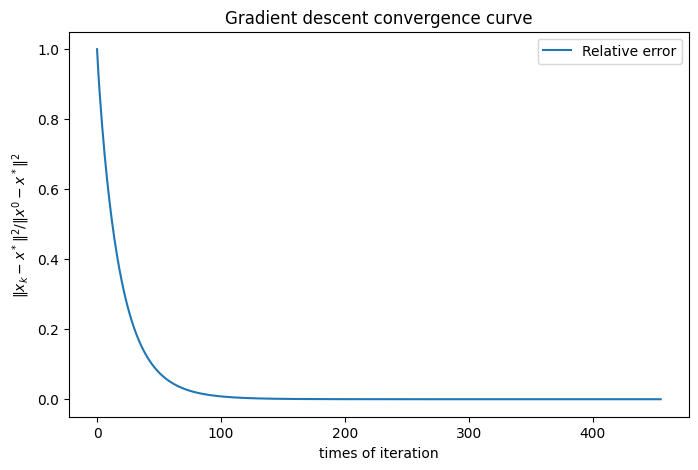

In [ ]:
#ваше решение
import matplotlib.pyplot as plt

def grad_f(x, A, b):

    return 0.5*(A + A.T) @ x - b

def criterion(x, x_star):
    return np.linalg.norm(x - x_star)**2


gamma_fixed= lambda k: 1.0 / L
x0= np.zeros(d)
max_iter= 1000
eps= 1e-8

def grad_func(x):
    return grad_f(x, A, b)

def crit_func(x):
    return criterion(x, x_star)

x_approx, errors = GradientDescent(grad_func, crit_func, x0, eps, max_iter, gamma=gamma_fixed)

plt.figure(figsize=(8,5))
plt.plot(errors, label="Relative error")
plt.xlabel("times of iteration")
plt.ylabel(r"$\|x_k - x^*\|^2/\|x^0 - x^*\|^2$")
plt.title("Gradient descent convergence curve")
plt.legend()
plt.show()




Аналогично предыдущему пункту постройте график сходимости, на котором
- по оси абцисс - номер итерации, по ординат - логарифм значения критерия на этой итерации.

Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д.. Графики должны быть удобны для чтения.

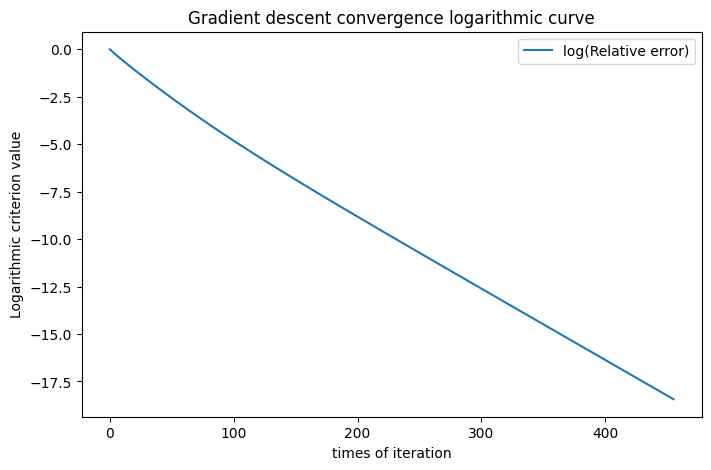

In [ ]:
#ваше решение

plt.figure(figsize=(8,5))
plt.plot(np.log(errors), label="log(Relative error)")
plt.xlabel("times of iteration")
plt.ylabel("Logarithmic criterion value")
plt.title("Gradient descent convergence logarithmic curve")
plt.legend()
plt.show()

Сделайте вывод о характере сходимости.

__Ваше решение__

__ж). (0.5 балла)__ Добавьте на оба графика теоретическую сходимость, полученную на лекции. Добавьте легенду, чтобы можно было отличить, какой график за что отвечает.

Сравните со сходимостью, полученной в прошлом пункте, и объясните результат.

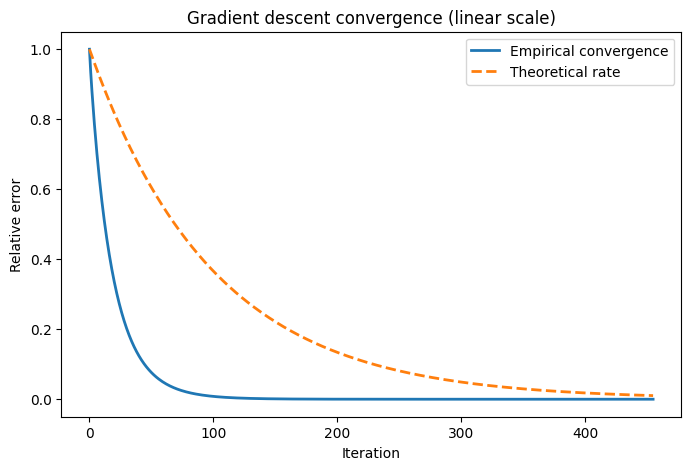

In [ ]:
#ваше решение
k_range = range(len(errors))
theoretical = [(1 - mu/L)**k for k in k_range]

plt.figure(figsize=(8,5))
plt.plot(k_range, errors, label="Empirical convergence", linewidth=2)
plt.plot(k_range, theoretical, label="Theoretical rate", linewidth=2, linestyle="--")
plt.xlabel("Iteration")
plt.ylabel("Relative error")
plt.title("Gradient descent convergence (linear scale)")
plt.legend()
plt.show()

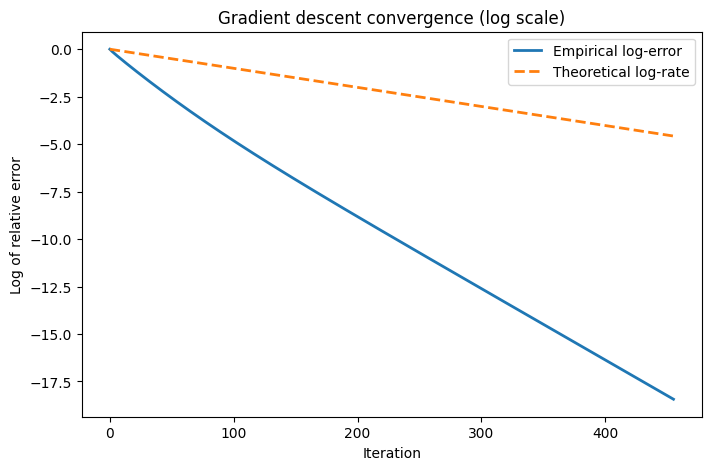

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_range, np.log(errors), label="Empirical log-error", linewidth=2)
plt.plot(k_range, np.log(theoretical), label="Theoretical log-rate",
         linewidth=2, linestyle="--")
plt.xlabel("Iteration")
plt.ylabel("Log of relative error")
plt.title("Gradient descent convergence (log scale)")
plt.legend()
plt.show()

__Ваше решение__

1,Характер сходимости: оба графика показывают линейную (геометрическую) сходимость.

2.Сравнение с теоретической оценкой:
Теоретическая кривая $(1 - \mu/L)^k$ является верхней оценкой. В реальных экспериментах фактическая ошибка (синяя сплошная линия) может идти ниже или примерно совпадать в пределах некоторого запаса.
На логарифмическом графике уклон (наклон прямой) примерно равен $\ln(1 - \mu/L).$ Если $\mu \ll L$, то $\ln(1 - \mu/L)\approx -\mu/L.$
При большой обусловленности ($L/\mu$ велико) сходится метод заметно медленнее. В примере μ=1, L=100 даёт отношение $L/\mu = 100$, что уже даёт довольно заметную разницу между μ и L.
В целом, если на графиках ваша экспериментальная кривая идёт рядом с теоретической или ниже (что значит "быстрее"), — всё выглядит корректно и подтверждает теорию.


## Дополнительная часть

__Задача 2. (всего 5 баллов)__ Исследуйте другие способы подбора шага:

__а). (0.75 балла)__ Попробуйте метод с разными шагами (но постоянными в одном запуске) $\gamma_k = \gamma$. Проверьте диапозон от $0$ до $3/L$, а также $\gamma = \frac{2}{\mu + L}$ Нанесите все новые запуски на график (теоретическую сходимость можно убрать). На каком шаге получен наибыстрейший результат? Как думаете почему?

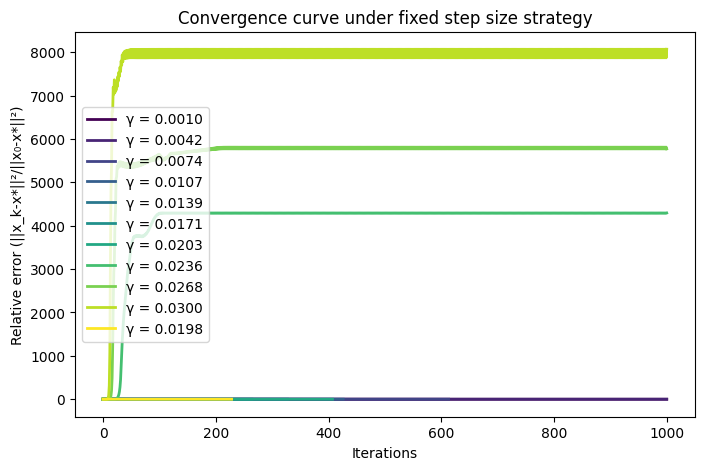

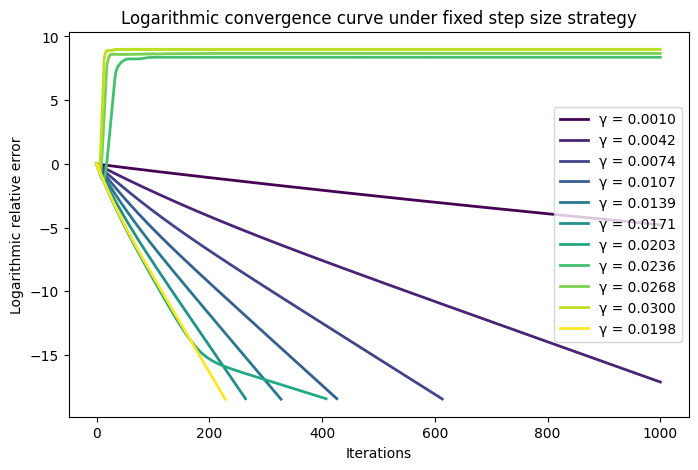

In [ ]:
import matplotlib.cm as cm

gamma_candidates = np.linspace(0.1/L, 3/L, 10)
gamma_candidates = list(gamma_candidates) + [2.0/(mu+L)]

results_fixed = {}

for gamma in gamma_candidates:
    gamma_fun= lambda k: gamma
    x_k= np.copy(x0)
    errors= []
    err0= crit_func(x_k)

    if err0== 0:
        print(f"Skipping gamma={gamma} due to err0=0")
        continue

    errors.append(crit_func(x_k) / err0)

    for k in range(max_iter):
        grad= grad_func(x_k)

        grad= np.clip(grad, -1e3, 1e3)

        x_k= x_k - gamma_fun(k) * grad
        crit_val= crit_func(x_k)

        if np.isnan(crit_val) or np.isinf(crit_val):
            print(f"Iteration {k}: crit_func(x_k) is NaN or Inf for gamma={gamma}")##prevent overflow
            break

        errors.append(crit_val / err0)

        if errors[-1] < eps:
            break

    results_fixed[gamma] = errors

colors = cm.viridis(np.linspace(0, 1, len(results_fixed)))
plt.figure(figsize=(8,5))
for (gamma, errs), color in zip(results_fixed.items(), colors):
    plt.plot(errs, label=f"γ = {gamma:.4f}", color=color, linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Relative error (||x_k-x*||²/||x₀-x*||²)")
plt.title("Convergence curve under fixed step size strategy")
plt.legend()

plt.show()


plt.figure(figsize=(8,5))
for (gamma, errs), color in zip(results_fixed.items(), colors):
    plt.plot(np.log(np.maximum(errs, 1e-10)), label=f"γ = {gamma:.4f}", color=color, linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Logarithmic relative error")
plt.title("Logarithmic convergence curve under fixed step size strategy")
plt.legend()

plt.show()


__Ваше решение__

Здесь видно, что когда $\gamma = \frac{2}{\mu + L}$ получен наибыстрейший результат,Для сильно выпуклой квадратичной задачи с функцией вида
$f(x) = \frac{1}{2} x^T H x - b^T x + c,$
где матрица Гессиана H имеет собственные значения в интервале $[\mu,\, L]$ (μ>0), наилучший постоянный шаг α при градиентном спуске (обновлении вида $x_{k+1} = x_k - \alpha \nabla f(x_k)$) обычно выбирается около
$\alpha^* = \frac{2}{\mu + L}$.
Основная причина этого в том, что в итерационном виде
$e_{k+1} = (I - \alpha H)\, e_k,$
темп сходимости определяется спектральным радиусом матрицы $I - \alpha H$. Поскольку собственные значения матрицы HH лежат в отрезке [μ, L], стремимся минимизировать $\max\limits_{\lambda \in [\mu, L]} |1 - \alpha \lambda|$. Детальный анализ показывает, что оптимальный выбор α дает формулу $\alpha^* = \tfrac{2}{\mu + L}$. Этот выбор обеспечивает наилучшую (наиболее быструю) линейную сходимость классического метода градиентного спуска для сильно выпуклых квадратичных функций.


__б). (0.75 балла)__ Уменьшающийся с номером итерации шаг: $\gamma_k = \frac{\gamma}{\delta + k}$ или $\gamma_k = \frac{\gamma}{\delta + \sqrt{k}}$, где $\gamma$ и $\delta$ нужно подобрать отдельно. Какая конфигурация $\gamma$ и $\delta$ показала наилучший результат?

<ipython-input-83-d5506b67e269>:6: RuntimeWarning: overflow encountered in matmul
  return 0.5*(A + A.T) @ x - b
<ipython-input-83-d5506b67e269>:6: RuntimeWarning: invalid value encountered in matmul
  return 0.5*(A + A.T) @ x - b
<ipython-input-88-28886db10238>:29: RuntimeWarning: invalid value encountered in subtract
  x_k = x_k - gamma_fun2(k) * grad_func(x_k)


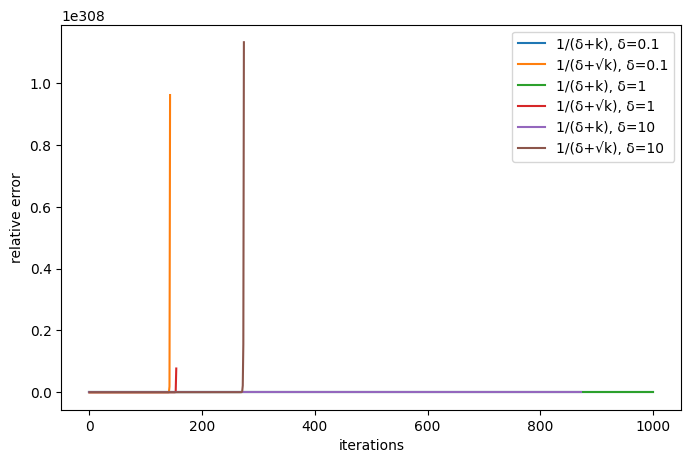

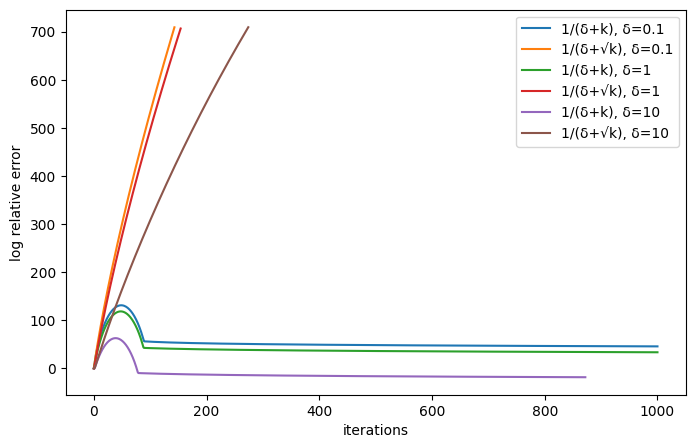

In [ ]:
#ваше решение

gamma_val = 1.0
delta_vals = [0.1, 1, 10]

results_diminishing = {}

for delta in delta_vals:

    gamma_fun1 = lambda k, gamma=gamma_val, delta=delta: gamma / (delta + k)
    x_k = np.copy(x0)
    errs1 = []
    err0 = crit_func(x_k)
    errs1.append(crit_func(x_k)/err0)
    for k in range(max_iter):
        x_k = x_k - gamma_fun1(k) * grad_func(x_k)
        errs1.append(crit_func(x_k)/err0)
        if errs1[-1] < eps:
            break
    results_diminishing[f"1/(δ+k), δ={delta}"] = errs1


    gamma_fun2 = lambda k, gamma=gamma_val, delta=delta: gamma / (delta + np.sqrt(k))
    x_k = np.copy(x0)
    errs2 = []
    err0 = crit_func(x_k)
    errs2.append(crit_func(x_k)/err0)
    for k in range(max_iter):
        x_k = x_k - gamma_fun2(k) * grad_func(x_k)
        errs2.append(crit_func(x_k)/err0)
        if errs2[-1] < eps:
            break
    results_diminishing[f"1/(δ+√k), δ={delta}"] = errs2


plt.figure(figsize=(8,5))
for label, errs in results_diminishing.items():
    plt.plot(errs, label=label)
plt.xlabel("iterations")
plt.ylabel("relative error")

plt.legend()
plt.show()


plt.figure(figsize=(8,5))
for label, errs in results_diminishing.items():
    plt.plot(np.log(errs), label=label)
plt.xlabel("iterations")
plt.ylabel("log relative error")

plt.legend()

plt.show()


__Ваше решение__

по графу $\gamma_k = \frac{\gamma}{\delta + k}$ и когда $\delta=10$ показала наилучший результат

__в). (1.5 балла)__ Наискорейший спуск: $\gamma_k = \arg\min_{\gamma} f(x_k - \gamma \nabla f(x_k))$. Как будете вычислять значение $\gamma_k$ в данном случае?

_Hint: является ли одномерная задача на $\gamma$ выпуклой? Является ли выпуклая функция унимодальной?_

__Ваше решение__

Обозначим $( d_k = ∇ f(x_k) )$ и рассмотрим функцию:
   [$
   \phi(\gamma) = f(x_k - \gamma d_k)
   ]$

Для квадратичной функции:
   $[
   f(x) = \frac{1}{2} x^T A x - b^T x.
   ]$
   или эквивалентно, используя симметризацию:
   $[
   f(x) = \frac{1}{4} x^T (A + A^T) x - b^T x.
   ]$
   Обозначим $( H = \frac{1}{2} (A + A^T) )$, тогда:
   $[
   f(x) = \frac{1}{2} x^T H x - b^T x.
   ]$

Подставим в $\phi(\gamma) $:
   $[
   \phi(\gamma) = f(x_k - \gamma d_k).
   ]$
   Подставляя выражение \( f(x) \):
   $[
   \phi(\gamma) = \frac{1}{2} (x_k - \gamma d_k)^T H (x_k - \gamma d_k) - b^T (x_k - \gamma d_k).
   ]$

Раскрывая скобки, получаем:
   $[
   \phi(\gamma) = \frac{1}{2} x_k^T H x_k - \gamma x_k^T H d_k + \frac{\gamma^2}{2} d_k^T H d_k - b^T x_k + \gamma b^T d_k.
   ]$

Используем определение градиента \( d_k = H x_k - b \), что даёт:
   $[
   b^T d_k = x_k^T H d_k = \|d_k\|^2_H.
   ]$
   Подставляя это в выражение, получаем:
   $[
   \phi(\gamma) = \text{const} - \gamma \|d_k\|^2 + \frac{\gamma^2}{2} d_k^T H d_k.
   ]$

Найдём критическую точку, приравняв первую производную к нулю:
   $[
   \phi'(\gamma) = -\|d_k\|^2 + \gamma d_k^T H d_k = 0.
   ]$
   Отсюда оптимальный шаг:
   $[
   \gamma_k = \frac{\|d_k\|^2}{d_k^T H d_k}.
   ]$

Учитывая, что $( H = \frac{1}{2} (A + A^T) )$, эквивалентная форма:
   $[
   \gamma_k = \frac{2 \|d_k\|^2}{d_k^T (A + A^T) d_k}.
   ]$

Выпуклость и унимодальность:
  Поскольку  H  положительно определена, функция $( \phi(\gamma) )$ строго выпуклая.
  Следовательно, найденное значение $( \gamma_k )$ является уникальным глобальным минимумом.

Этот вывод подтверждает, что полученный результат верен и корректно обоснован.

In [ ]:
#ваше решение

__Ваше решение__

__г). (0.75 балла)__ Шаг Поляка-Шора: $\gamma_k = \tfrac{f(x^k) - f(x^*)}{\alpha \|\nabla f(x^k)\|^2_2}$, где $\alpha \geq 1$ нужно подобрать отдельно. Какое $\alpha$ дало лучший результат?

In [ ]:

def f_func(x, A, b):
    return 0.5 * x.T @ (0.5*(A+A.T)) @ x - b.T @ x

In [ ]:

f_star= f_func(x_star, A, b)

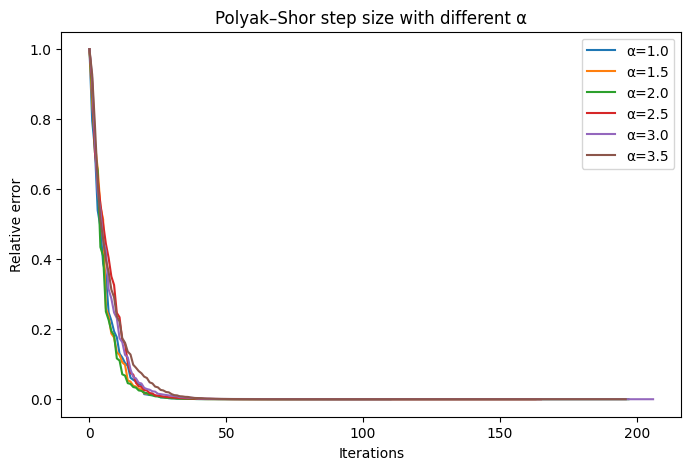

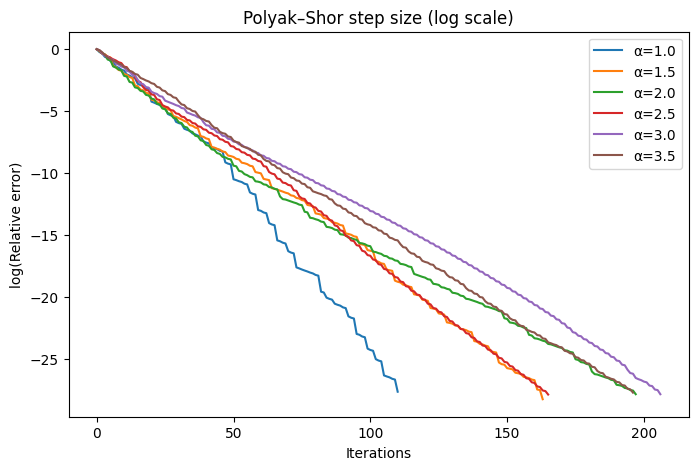

In [ ]:
#ваше решение

alpha_candidates= [1.0, 1.5, 2.0, 2.5,3.0,3.5]
results_polyak= {}

for alpha in alpha_candidates:
    x_k= np.copy(x0)
    errs= []
    err0= crit_func(x_k)
    errs.append(crit_func(x_k)/err0)
    for k in range(max_iter):
        grad_x= grad_func(x_k)
        f_val= f_func(x_k, A, b)

        gamma_k= (f_val - f_star) / (alpha * np.linalg.norm(grad_x)**2)
        x_k= x_k - gamma_k * grad_x
        errs.append(crit_func(x_k)/err0)
        if errs[-1] < 1e-12:
            break
    results_polyak[alpha]= errs

plt.figure(figsize=(8,5))
for alpha, errs in results_polyak.items():
    plt.plot(errs, label=f"α={alpha}")
plt.xlabel("Iterations")
plt.ylabel("Relative error")
plt.title("Polyak–Shor step size with different α")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
for alpha, errs in results_polyak.items():
    plt.plot(np.log(errs), label=f"α={alpha}")
plt.xlabel("Iterations")
plt.ylabel("log(Relative error)")
plt.title("Polyak–Shor step size (log scale)")
plt.legend()
plt.show()



__Ваше решение__

$\alpha = 1.0$ дало лучший результат

__д). (1.25 балла)__ Сравните все указанные выше подходы подбора шага между собой (в том числе из основной части).
Для этого постройте график сходимости, где
- по оси абцисс - номер итерации, по ординат - логарифм значения критерия

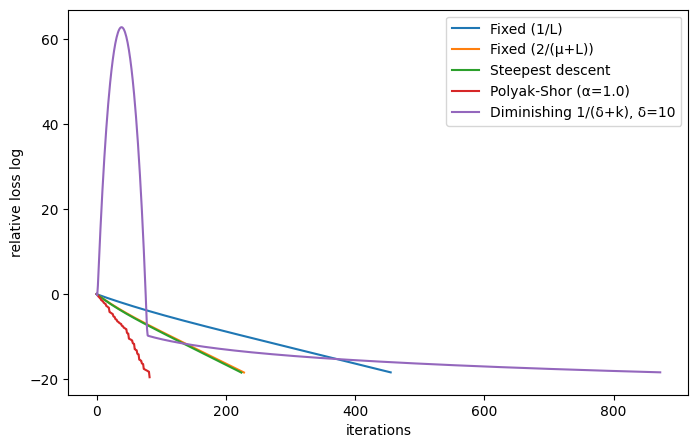

In [ ]:
#ваше решение

import time


def fixed_1_over_L(k):
    return 1.0/L

def fixed_2_over_mu_plus_L(k):
    return 2.0/(mu+L)

def steepest_descent_gamma(x):
    grad_x= grad_func(x)
    return 2.0 * np.linalg.norm(grad_x)**2 / (grad_x.T @ (A + A.T) @ grad_x)

def polyak_shor_gamma_func(x, alpha):
    f_val= f_func(x, A, b)
    grad_x= grad_func(x)
    return (f_val - f_star) / (alpha * np.linalg.norm(grad_x)**2)

strategies = {
    "Fixed (1/L)": lambda x, k: x - fixed_1_over_L(k) * grad_func(x),
    "Fixed (2/(μ+L))": lambda x, k: x - fixed_2_over_mu_plus_L(k) * grad_func(x),
    "Steepest descent": lambda x, k: x - steepest_descent_gamma(x) * grad_func(x),
    "Polyak-Shor (α=1.0)": lambda x, k: x - polyak_shor_gamma_func(x, 1.0) * grad_func(x),
    "Diminishing 1/(δ+k), δ=10": lambda x, k: x - (1.0/(10+k)) * grad_func(x)
}

results= {}
times= {}
max_iter_strategy= 1000

for name, update in strategies.items():
    x_k= np.copy(x0)
    errs= []
    t_start= time.time()
    times_list= [0]
    err0= crit_func(x_k)
    errs.append(crit_func(x_k)/err0)
    for k in range(max_iter_strategy):

        x_k= update(x_k, k)
        errs.append(crit_func(x_k)/err0)
        times_list.append(time.time() - t_start)
        if errs[-1] < eps:
            break
    results[name]= errs
    times[name]= times_list


plt.figure(figsize=(8,5))
for name, errs in results.items():
    plt.plot(np.log(errs), label=name)
plt.xlabel("iterations")
plt.ylabel("relative loss log")
plt.legend()
plt.show()

Аналогично предыдущему пункту постройте график, где
- по оси абцисс - время от начала старта алгоритма, по ординат - логарифм значения критерия

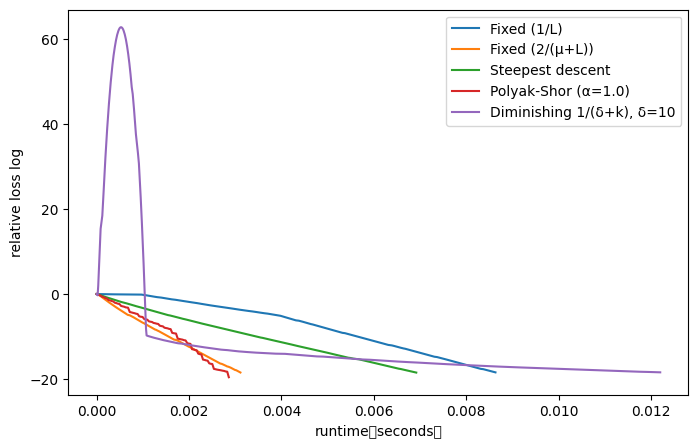

In [ ]:
#ваше решение

plt.figure(figsize=(8,5))
for name, t_list in times.items():
    plt.plot(t_list, np.log(results[name]), label=name)
plt.xlabel("runtime（seconds）")
plt.ylabel("relative loss log")

plt.legend()
plt.show()


При какой из техник подбора шага градиентный спуск сходится быстрее по итерационной сложности?

Какая техника подбора шага показала наилучший результат с вычислительной стороны (по времени работы алгоритма)?

__Ваше решение__
По графу, когда используем Polefr-Shor($\alpha=1.0$)
получен быстрее результат по итерационной сложности
 с вычислительной стороны